# Scratch ViT BBox-Aware Interpretability Visualization

This notebook visualizes interpretability heatmaps for the custom scratch ViT baseline using **explicitly selected NIH disease cases with bounding-box annotations**.

It supports:
- single-layer CLS attention heatmaps
- attention rollout heatmaps
- bbox overlays and simple localization metrics

It does **not** use Grad-CAM and does **not** retrain the model.


In [54]:
from pathlib import Path
import sys
import random
from typing import Sequence

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display
from torch.utils.data import DataLoader, Subset

REPO_ROOT = Path("..").resolve()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from train import load_config, merge_dicts, resolve_device
from models import build_model
from data import build_nih_data_module
from interpretability import build_cls_attention_heatmap

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams["figure.figsize"] = (16, 4)
plt.rcParams["axes.titlesize"] = 10
plt.rcParams["figure.dpi"] = 120


In [58]:
import os 
print(os.getcwd())
REPO_ROOT = Path(os.getcwd()).resolve()

/home/nate/Documents/omscs/dl/final_project/visiontrans_diagnostics


In [59]:
BASE_CONFIG = REPO_ROOT / "configs/vit_baseline.yaml"
CHECKPOINT_PATH = REPO_ROOT / "artifacts/experiments/final_vit_baseline_fixed/checkpoints/vit_best_auc.pt"
# CHECKPOINT_PATH = REPO_ROOT / "artifacts/experiments/final_vit_baseline_fixed_smoke/checkpoints/vit_best_auc.pt"

SPLIT = "test"  # align with run_interpretability.ipynb; switch to "val" if needed
SELECTED_BBOX_CASES = [
    ("Cardiomegaly", 0),
    ("Pneumothorax", 0),
]
SINGLE_LABEL_ONLY = True
FILTER_CORRECT_ARGMAX = False

LAYER_INDEX = -1
HEAD_REDUCTION = "mean"
ROLLOUT_HEAD_REDUCTION = "mean"
ROLLOUT_DISCARD_RATIO = 0.0
HEATMAP_PERCENTILE = 80.0
TOP_K_PREDICTIONS = 5

SELECTED_BATCH_SIZE = 1
NUM_WORKERS = 0

OUTPUT_ROOT = REPO_ROOT / "artifacts/interpretability"
FIGURE_OUTPUT_DIR = OUTPUT_ROOT / "vit_bbox_attention_examples"
SELECTED_SAMPLES_CSV = OUTPUT_ROOT / "selected_bbox_samples.csv"
METRICS_CSV = OUTPUT_ROOT / "vit_bbox_attention_metrics.csv"


In [60]:
if not BASE_CONFIG.exists():
    raise FileNotFoundError(f"Base config not found: {BASE_CONFIG}")
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}")

base_config = load_config(BASE_CONFIG)
checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
checkpoint_config = checkpoint.get("config", {})
config = merge_dicts(base_config, checkpoint_config)
device = resolve_device(config)

data_module = build_nih_data_module(config)
available_splits = list(data_module["dataloaders"].keys())
if SPLIT not in available_splits:
    raise ValueError(f"Requested split={SPLIT!r}, but available splits are {available_splits}")

split_loader = data_module["dataloaders"][SPLIT]
split_dataset = split_loader.dataset
manifest_df = split_dataset.frame.reset_index(drop=True).copy()
if "image_name" not in manifest_df.columns and "Image Index" in manifest_df.columns:
    manifest_df = manifest_df.rename(columns={"Image Index": "image_name"})
if "image_name" not in manifest_df.columns:
    raise ValueError(f"Manifest for split={SPLIT!r} must contain 'image_name'. Found: {list(manifest_df.columns)}")
if "image_path" not in manifest_df.columns:
    raise ValueError(f"Manifest for split={SPLIT!r} must contain 'image_path'. Found: {list(manifest_df.columns)}")

label_names = list(data_module["labels"])
missing_label_columns = [label for label in label_names if label not in manifest_df.columns]
if missing_label_columns:
    raise ValueError(f"Manifest is missing NIH label columns: {missing_label_columns}")

data_config = config.get("data", {})
model_config = config.get("model", {})
image_size = int(data_config.get("image_size", 224))
patch_size = int(model_config.get("patch_size", 16))
num_channels = int(data_config.get("num_channels", 1))
mean = tuple(float(v) for v in data_config.get("normalize_mean", [0.5]))
std = tuple(float(v) for v in data_config.get("normalize_std", [0.25]))

print("Device:", device)
print("Checkpoint:", CHECKPOINT_PATH)
print("Split:", SPLIT)
print("Manifest rows:", len(manifest_df))
print("Label columns:", label_names)
print("Image size:", image_size)
print("Patch size:", patch_size)
print("Num channels:", num_channels)


Device: cuda
Checkpoint: /home/nate/Documents/omscs/dl/final_project/visiontrans_diagnostics/artifacts/experiments/final_vit_baseline_fixed/checkpoints/vit_best_auc.pt
Split: test
Manifest rows: 25596
Label columns: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia']
Image size: 224
Patch size: 16
Num channels: 1


In [61]:
def resolve_bbox_path(annotations_dir: Path) -> Path | None:
    annotations_dir = Path(annotations_dir)
    for candidate in ("BBox_List_2017.csv", "BBox_list_2017.csv"):
        candidate_path = annotations_dir / candidate
        if candidate_path.exists():
            return candidate_path
    return None


def load_bbox_annotations(bbox_path: Path) -> pd.DataFrame:
    bbox_df = pd.read_csv(bbox_path)
    bbox_df = bbox_df.loc[:, ~bbox_df.columns.astype(str).str.startswith("Unnamed")].copy()

    rename_map = {}
    for column in bbox_df.columns:
        normalized = " ".join(
            str(column).strip().lower().replace("[", " ").replace("]", " ").replace("_", " ").split()
        )
        compact = normalized.replace(" ", "")
        if normalized == "image index":
            rename_map[column] = "image_name"
        elif normalized == "finding label":
            rename_map[column] = "label"
        elif compact in {"bboxx", "x"}:
            rename_map[column] = "x"
        elif compact in {"bboxy", "y"}:
            rename_map[column] = "y"
        elif compact in {"bboxw", "w"}:
            rename_map[column] = "w"
        elif compact in {"bboxh", "h"}:
            rename_map[column] = "h"

    bbox_df = bbox_df.rename(columns=rename_map)
    required_columns = {"image_name", "label", "x", "y", "w", "h"}
    if not required_columns.issubset(bbox_df.columns):
        raise ValueError(
            "Bounding-box CSV is missing required columns. "
            f"Required={sorted(required_columns)} Found={list(bbox_df.columns)}"
        )

    bbox_df["image_name"] = bbox_df["image_name"].astype(str)
    bbox_df["label"] = bbox_df["label"].astype(str)
    return bbox_df


bbox_path = resolve_bbox_path(Path(data_config["annotations_dir"]))
if bbox_path is None:
    bbox_df = None
    print("No NIH bbox CSV found under annotations_dir. Check BBox_List_2017.csv.")
else:
    bbox_df = load_bbox_annotations(bbox_path)
    print("BBox CSV path:", bbox_path)
    print("BBox rows loaded:", len(bbox_df))
    print("Unique bbox images:", bbox_df["image_name"].nunique())
    print("Available bbox labels:", sorted(bbox_df["label"].astype(str).unique().tolist()))


BBox CSV path: data/annotations/BBox_List_2017.csv
BBox rows loaded: 984
Unique bbox images: 880
Available bbox labels: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltrate', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax']


In [62]:
def add_gt_label(manifest_df: pd.DataFrame, label_cols: list[str]) -> pd.DataFrame:
    manifest_df = manifest_df.copy().reset_index(drop=True)
    label_sums = manifest_df[label_cols].sum(axis=1)
    single_df = manifest_df[label_sums == 1].copy().reset_index(drop=True)
    single_df["gt_label"] = single_df[label_cols].astype("float32").to_numpy().argmax(axis=1)
    single_df["gt_label"] = single_df["gt_label"].map(lambda idx: label_cols[int(idx)])
    return single_df


def build_bbox_candidate_index(
    manifest_df: pd.DataFrame,
    bbox_df: pd.DataFrame,
    label_cols: list[str],
    single_label_only: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    working_manifest = manifest_df.copy().reset_index(drop=True)
    working_manifest["dataset_index"] = working_manifest.index
    manifest_with_gt = add_gt_label(working_manifest, label_cols) if single_label_only else working_manifest.copy()
    candidate_df = manifest_with_gt.merge(bbox_df, on="image_name", how="inner", suffixes=("", "_bbox"))
    candidate_df = candidate_df[candidate_df["label"].astype(str).isin(label_cols)].copy()
    candidate_df = candidate_df.sort_values(
        ["label", "gt_label", "image_name", "dataset_index", "x", "y", "w", "h"],
        kind="stable",
    ).reset_index(drop=True)
    return manifest_with_gt, candidate_df


def build_subset_loader(dataset, dataset_indices: list[int], batch_size: int, num_workers: int = 0) -> DataLoader:
    subset = Subset(dataset, dataset_indices)
    return DataLoader(
        subset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=num_workers > 0,
    )


def optionally_filter_correct_argmax(
    candidate_df: pd.DataFrame,
    dataset,
    model,
    device: torch.device,
    label_cols: list[str],
    enabled: bool = False,
    batch_size: int = 8,
    num_workers: int = 0,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    unique_images = (
        candidate_df.drop_duplicates(subset=["dataset_index"], keep="first")
        .sort_values(["gt_label", "image_name", "dataset_index"], kind="stable")
        .reset_index(drop=True)
    )

    if not enabled:
        unique_images = unique_images.copy()
        unique_images["pred_top_label"] = pd.NA
        unique_images["pred_top_prob"] = np.nan
        unique_images["argmax_matches_gt"] = pd.NA
        candidate_with_preds = candidate_df.merge(
            unique_images[["dataset_index", "pred_top_label", "pred_top_prob", "argmax_matches_gt"]],
            on="dataset_index",
            how="left",
        )
        return candidate_with_preds, unique_images

    if "gt_label" not in unique_images.columns:
        raise ValueError("Correct-argmax filtering requires a single-label candidate index with 'gt_label'.")

    dataset_indices = unique_images["dataset_index"].astype(int).tolist()
    subset_loader = build_subset_loader(dataset, dataset_indices, batch_size=batch_size, num_workers=num_workers)
    top_labels = []
    top_probs = []
    with torch.inference_mode():
        for images, _ in subset_loader:
            logits = model(images.to(device))
            probs = torch.sigmoid(logits).detach().cpu()
            batch_probs, batch_indices = probs.max(dim=1)
            top_probs.extend(batch_probs.tolist())
            top_labels.extend([label_cols[int(idx)] for idx in batch_indices.tolist()])

    unique_images = unique_images.copy()
    unique_images["pred_top_label"] = top_labels
    unique_images["pred_top_prob"] = top_probs
    unique_images["argmax_matches_gt"] = unique_images["pred_top_label"] == unique_images["gt_label"]

    filtered_indices = set(unique_images.loc[unique_images["argmax_matches_gt"], "dataset_index"].astype(int).tolist())
    filtered_candidates = candidate_df[candidate_df["dataset_index"].astype(int).isin(filtered_indices)].copy()
    filtered_candidates = filtered_candidates.merge(
        unique_images[["dataset_index", "pred_top_label", "pred_top_prob", "argmax_matches_gt"]],
        on="dataset_index",
        how="left",
    )
    filtered_candidates = filtered_candidates.reset_index(drop=True)
    return filtered_candidates, unique_images


def select_requested_bbox_cases(
    candidate_df: pd.DataFrame,
    selected_cases: list[tuple[str, int]],
) -> tuple[pd.DataFrame, list[str]]:
    selected_groups = []
    diagnostics = []
    for disease, sample_index in selected_cases:
        disease_candidates = candidate_df[
            (candidate_df["gt_label"].astype(str) == str(disease))
            | (candidate_df["label"].astype(str) == str(disease))
        ].copy()
        disease_images = (
            disease_candidates.drop_duplicates(subset=["dataset_index"], keep="first")
            .sort_values(["image_name", "dataset_index"], kind="stable")
            .reset_index(drop=True)
        )
        diagnostics.append(f"{disease}: {len(disease_images)} candidate image(s)")
        if sample_index >= len(disease_images):
            diagnostics.append(
                f"Skipping ({disease}, {sample_index}) because only {len(disease_images)} candidate image(s) are available."
            )
            continue
        selected_image = disease_images.iloc[sample_index]
        dataset_index = int(selected_image["dataset_index"])
        selected_rows = disease_candidates[disease_candidates["dataset_index"].astype(int) == dataset_index].copy()
        selected_rows["requested_disease"] = disease
        selected_rows["requested_case_index"] = sample_index
        selected_groups.append(selected_rows)

    if not selected_groups:
        return pd.DataFrame(), diagnostics
    selected_df = pd.concat(selected_groups, ignore_index=True)
    selected_df = selected_df.sort_values(
        ["requested_disease", "requested_case_index", "image_name", "x", "y", "w", "h"],
        kind="stable",
    ).reset_index(drop=True)
    return selected_df, diagnostics


In [63]:
model = build_model(config).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded model:", model.__class__.__name__)
print("Checkpoint keys:", sorted(checkpoint.keys()))
print("FILTER_CORRECT_ARGMAX:", FILTER_CORRECT_ARGMAX)


Loaded model: VisionTransformerClassifier
Checkpoint keys: ['best_auc', 'best_macro_f1', 'config', 'early_stopping_state', 'epoch', 'model_state_dict', 'optimizer_state_dict', 'pos_weight_stats', 'scheduler_state_dict', 'val_metrics']
FILTER_CORRECT_ARGMAX: False


In [64]:
requested_labels = [disease for disease, _ in SELECTED_BBOX_CASES]
if bbox_df is None:
    single_manifest_df = pd.DataFrame()
    candidate_df = pd.DataFrame()
    prediction_index_df = pd.DataFrame()
    selected_case_rows = pd.DataFrame()
    print("Cannot build bbox candidate index because the bbox CSV was not found.")
else:
    single_manifest_df, candidate_df = build_bbox_candidate_index(
        manifest_df=manifest_df,
        bbox_df=bbox_df,
        label_cols=label_names,
        single_label_only=SINGLE_LABEL_ONLY,
    )
    print("Single-label rows:", len(single_manifest_df))
    print("Candidate bbox rows after split merge:", len(candidate_df))
    print(
        "Manifest image names matching bbox image names:",
        len(set(manifest_df["image_name"].astype(str)) & set(bbox_df["image_name"].astype(str))),
    )
    print("Requested labels:", requested_labels)
    for disease in requested_labels:
        disease_count = candidate_df[
            (candidate_df["gt_label"].astype(str) == disease)
            | (candidate_df["label"].astype(str) == disease)
        ]["dataset_index"].nunique()
        print(f"Candidate images for {disease}: {disease_count}")

    filtered_candidate_df, prediction_index_df = optionally_filter_correct_argmax(
        candidate_df=candidate_df,
        dataset=split_dataset,
        model=model,
        device=device,
        label_cols=label_names,
        enabled=FILTER_CORRECT_ARGMAX,
        batch_size=8,
        num_workers=NUM_WORKERS,
    )

    if FILTER_CORRECT_ARGMAX:
        before_counts = (
            candidate_df[["dataset_index", "gt_label"]]
            .drop_duplicates()
            .groupby("gt_label")
            .size()
            .sort_index()
        )
        after_counts = (
            filtered_candidate_df[["dataset_index", "gt_label"]]
            .drop_duplicates()
            .groupby("gt_label")
            .size()
            .sort_index()
        )
        print("Counts before correct-argmax filter:")
        print(before_counts)
        print("Counts after correct-argmax filter:")
        print(after_counts)
        if filtered_candidate_df.empty:
            print("FILTER_CORRECT_ARGMAX removed all candidates. Set FILTER_CORRECT_ARGMAX=False to keep bbox cases.")

    selected_case_rows, selection_diagnostics = select_requested_bbox_cases(
        filtered_candidate_df,
        selected_cases=SELECTED_BBOX_CASES,
    )
    for message in selection_diagnostics:
        print(message)

    if selected_case_rows.empty:
        print("No requested bbox cases were selected. Check the diagnostics above.")
    else:
        display(
            selected_case_rows[
                [
                    "requested_disease",
                    "requested_case_index",
                    "image_name",
                    "gt_label",
                    "label",
                    "x",
                    "y",
                    "w",
                    "h",
                    "image_path",
                ]
            ]
        )


Single-label rows: 7992
Candidate bbox rows after split merge: 237
Manifest image names matching bbox image names: 880
Requested labels: ['Cardiomegaly', 'Pneumothorax']
Candidate images for Cardiomegaly: 59
Candidate images for Pneumothorax: 34
Cardiomegaly: 59 candidate image(s)
Pneumothorax: 34 candidate image(s)


,requested_disease,requested_case_index,image_name,gt_label,label,x,y,w,h,image_path
0,Cardiomegaly,0,00000377_004.png,Cardiomegaly,Cardiomegaly,387.796610,419.525424,502.237288,367.728814,/home/nate/Documents/omscs/dl/final_project/vi...
1,Pneumothorax,0,00001946_029.png,Pneumothorax,Pneumothorax,289.564444,396.269045,72.817778,154.737778,/home/nate/Documents/omscs/dl/final_project/vi...


In [65]:
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if selected_case_rows.empty:
    selected_subset_loader = None
    selected_case_images = pd.DataFrame()
    selected_dataset_indices = []
    print("Selected-sample loader was not created because no requested bbox cases were found.")
else:
    selected_dataset_indices = list(dict.fromkeys(selected_case_rows["dataset_index"].astype(int).tolist()))
    selected_case_images = (
        selected_case_rows.drop_duplicates(subset=["dataset_index"], keep="first")
        .sort_values(["requested_disease", "requested_case_index", "image_name"], kind="stable")
        .reset_index(drop=True)
    )
    selected_subset_loader = build_subset_loader(
        split_dataset,
        dataset_indices=selected_dataset_indices,
        batch_size=SELECTED_BATCH_SIZE,
        num_workers=NUM_WORKERS,
    )
    selected_case_rows.to_csv(SELECTED_SAMPLES_CSV, index=False)
    print("Selected images:", len(selected_case_images))
    print("Selected loader batches:", len(selected_subset_loader))
    print("Saved selected bbox samples CSV to:", SELECTED_SAMPLES_CSV)


Selected images: 2
Selected loader batches: 2
Saved selected bbox samples CSV to: /home/nate/Documents/omscs/dl/final_project/visiontrans_diagnostics/artifacts/interpretability/selected_bbox_samples.csv


In [66]:
def denormalize_image(image_tensor: torch.Tensor, mean: Sequence[float], std: Sequence[float]) -> np.ndarray:
    image = image_tensor.detach().cpu().clone().float()
    for channel_index, (channel_mean, channel_std) in enumerate(zip(mean, std)):
        image[channel_index] = image[channel_index] * channel_std + channel_mean
    image = image.clamp(0.0, 1.0)
    if image.size(0) == 1:
        image = image.repeat(3, 1, 1)
    return image.permute(1, 2, 0).numpy()


def overlay_heatmap(image_array: np.ndarray, heatmap: torch.Tensor, alpha: float = 0.35) -> np.ndarray:
    base = np.clip(image_array, 0.0, 1.0)
    heatmap_array = heatmap.detach().cpu().squeeze().numpy()
    colored = plt.cm.jet(heatmap_array)[..., :3]
    return np.clip((1.0 - alpha) * base + alpha * colored, 0.0, 1.0)


def get_top_labels(logit_tensor: torch.Tensor, label_names: Sequence[str], k: int = 5) -> list[tuple[str, float]]:
    probabilities = torch.sigmoid(logit_tensor.detach().cpu())
    top_scores, top_indices = torch.topk(probabilities, k=min(k, len(label_names)))
    return [(label_names[idx], float(score)) for score, idx in zip(top_scores.tolist(), top_indices.tolist())]


def resolve_layer_index(layer_index: int | str, num_layers: int) -> int:
    if isinstance(layer_index, str):
        if layer_index == "middle":
            return num_layers // 2
        return int(layer_index)
    return int(layer_index)


def compute_attention_rollout(attn_maps: list[torch.Tensor], head_reduction: str = "mean", discard_ratio: float = 0.0) -> torch.Tensor:
    if not attn_maps:
        raise ValueError("attn_maps is empty. Run the model with return_attention=True first.")

    rollout = None
    for layer_attention in attn_maps:
        if layer_attention.ndim != 4:
            raise ValueError(
                f"Expected attention map with shape (B, heads, seq_len, seq_len), got {tuple(layer_attention.shape)}"
            )
        if head_reduction == "mean":
            fused = layer_attention.mean(dim=1)
        elif head_reduction == "max":
            fused = layer_attention.max(dim=1).values
        else:
            raise ValueError("head_reduction must be 'mean' or 'max'.")

        fused = fused.clone()
        if discard_ratio > 0:
            cls_column = fused[:, :, 0].clone()
            flattened = fused.reshape(fused.size(0), -1)
            num_discard = int(flattened.size(1) * discard_ratio)
            if num_discard > 0:
                threshold = torch.topk(flattened, k=num_discard, dim=1, largest=False).values[:, -1]
                mask = fused <= threshold.view(-1, 1, 1)
                fused[mask] = 0.0
                fused[:, :, 0] = cls_column

        identity = torch.eye(fused.size(-1), device=fused.device).unsqueeze(0)
        fused = fused + identity
        fused = fused / fused.sum(dim=-1, keepdim=True).clamp_min(1e-8)
        rollout = fused if rollout is None else torch.bmm(fused, rollout)

    return rollout


def rollout_to_heatmap(
    attn_maps: list[torch.Tensor],
    image_size: int,
    patch_size: int,
    head_reduction: str = "mean",
    discard_ratio: float = 0.0,
) -> tuple[torch.Tensor, torch.Tensor]:
    if image_size % patch_size != 0:
        raise ValueError("image_size must be divisible by patch_size.")

    rollout = compute_attention_rollout(attn_maps, head_reduction=head_reduction, discard_ratio=discard_ratio)
    batch_size, seq_len, _ = rollout.shape
    grid_size = image_size // patch_size
    expected_patches = grid_size * grid_size
    if seq_len - 1 != expected_patches:
        raise ValueError(
            f"Expected {expected_patches} patches from seq_len={seq_len}, image_size={image_size}, patch_size={patch_size}."
        )

    cls_to_patches = rollout[:, 0, 1:]
    patch_grid = cls_to_patches.reshape(batch_size, grid_size, grid_size)
    heatmap = F.interpolate(
        patch_grid.unsqueeze(1),
        size=(image_size, image_size),
        mode="bilinear",
        align_corners=False,
    )
    heatmap_min = heatmap.amin(dim=(2, 3), keepdim=True)
    heatmap_max = heatmap.amax(dim=(2, 3), keepdim=True)
    heatmap = (heatmap - heatmap_min) / (heatmap_max - heatmap_min).clamp_min(1e-8)
    return patch_grid, heatmap


_missing_size_warning = {"emitted": False}

def resolve_original_size(metadata: dict[str, object]) -> tuple[float, float]:
    original_width = metadata.get("original_width")
    original_height = metadata.get("original_height")
    if original_width in (None, "", 0) or original_height in (None, "", 0):
        if not _missing_size_warning["emitted"]:
            print("original_width/original_height missing for at least one sample; assuming 1024x1024.")
            _missing_size_warning["emitted"] = True
        return 1024.0, 1024.0
    return float(original_width), float(original_height)


def draw_bboxes_on_axis(ax, boxes: pd.DataFrame, image_size: int, original_width: float, original_height: float) -> None:
    if boxes is None or boxes.empty:
        return
    scale_x = image_size / max(float(original_width), 1.0)
    scale_y = image_size / max(float(original_height), 1.0)
    for _, row in boxes.iterrows():
        x = float(row["x"]) * scale_x
        y = float(row["y"]) * scale_y
        w = float(row["w"]) * scale_x
        h = float(row["h"]) * scale_y
        ax.add_patch(Rectangle((x, y), w, h, linewidth=1.5, edgecolor="lime", facecolor="none"))


def compute_bbox_localization_metrics(
    heatmap: torch.Tensor,
    boxes: pd.DataFrame,
    image_size: int,
    original_width: float,
    original_height: float,
    heatmap_percentile: float = 80.0,
) -> dict[str, float]:
    if boxes is None or boxes.empty:
        return {
            "attention_bbox_overlap": float("nan"),
            "attention_bbox_iou": float("nan"),
            "heatmap_mass_inside_bbox": float("nan"),
        }

    heatmap_array = heatmap.detach().cpu().squeeze().numpy()
    threshold_value = float(np.percentile(heatmap_array, heatmap_percentile))
    attention_mask = heatmap_array >= threshold_value

    bbox_mask = np.zeros((image_size, image_size), dtype=bool)
    scale_x = image_size / max(float(original_width), 1.0)
    scale_y = image_size / max(float(original_height), 1.0)
    for _, row in boxes.iterrows():
        x0 = max(0, int(np.floor(float(row["x"]) * scale_x)))
        y0 = max(0, int(np.floor(float(row["y"]) * scale_y)))
        x1 = min(image_size, int(np.ceil((float(row["x"]) + float(row["w"])) * scale_x)))
        y1 = min(image_size, int(np.ceil((float(row["y"]) + float(row["h"])) * scale_y)))
        if x1 > x0 and y1 > y0:
            bbox_mask[y0:y1, x0:x1] = True

    intersection = np.logical_and(attention_mask, bbox_mask).sum()
    union = np.logical_or(attention_mask, bbox_mask).sum()
    bbox_area = bbox_mask.sum()
    total_mass = float(heatmap_array.sum())
    mass_inside_bbox = float(heatmap_array[bbox_mask].sum()) if bbox_mask.any() else float("nan")
    return {
        "attention_bbox_overlap": float(intersection / bbox_area) if bbox_area > 0 else float("nan"),
        "attention_bbox_iou": float(intersection / union) if union > 0 else float("nan"),
        "heatmap_mass_inside_bbox": float(mass_inside_bbox / total_mass) if total_mass > 0 else float("nan"),
    }


def generate_attention_records(
    model,
    selected_loader: DataLoader,
    selected_case_rows: pd.DataFrame,
    selected_case_images: pd.DataFrame,
    label_names: Sequence[str],
    device: torch.device,
    image_size: int,
    patch_size: int,
    mean: Sequence[float],
    std: Sequence[float],
    layer_index: int | str,
    head_reduction: str,
    rollout_head_reduction: str,
    rollout_discard_ratio: float,
    heatmap_percentile: float,
    top_k: int = 5,
) -> list[dict[str, object]]:
    if selected_loader is None:
        return []

    records: list[dict[str, object]] = []
    sample_offset = 0
    resolved_layer_index = None

    for batch_images, batch_labels in selected_loader:
        batch_size = batch_images.size(0)
        batch_meta = selected_case_images.iloc[sample_offset : sample_offset + batch_size].reset_index(drop=True)
        sample_offset += batch_size

        with torch.inference_mode():
            batch_logits, batch_attn_maps = model(batch_images.to(device), return_attention=True)

        if resolved_layer_index is None:
            resolved_layer_index = resolve_layer_index(layer_index, len(batch_attn_maps))

        batch_logits_cpu = batch_logits.detach().cpu()
        batch_attn_maps_cpu = [attention.detach().cpu() for attention in batch_attn_maps]
        _, single_heatmaps = build_cls_attention_heatmap(
            batch_attn_maps_cpu,
            image_size=image_size,
            patch_size=patch_size,
            layer_index=resolved_layer_index,
            head_reduction=head_reduction,
        )
        _, rollout_heatmaps = rollout_to_heatmap(
            batch_attn_maps_cpu,
            image_size=image_size,
            patch_size=patch_size,
            head_reduction=rollout_head_reduction,
            discard_ratio=rollout_discard_ratio,
        )

        for local_index in range(batch_size):
            metadata = batch_meta.iloc[local_index].to_dict()
            dataset_index = int(metadata["dataset_index"])
            rows_for_image = selected_case_rows[selected_case_rows["dataset_index"].astype(int) == dataset_index].copy()
            boxes = rows_for_image[["label", "x", "y", "w", "h"]].copy().reset_index(drop=True)
            image_name = str(metadata["image_name"])
            original_width, original_height = resolve_original_size(metadata)
            gt_label = str(metadata.get("gt_label", "Unknown"))
            requested_disease = str(metadata.get("requested_disease", gt_label))
            bbox_label_text = ", ".join(sorted(set(boxes["label"].astype(str).tolist()))) if not boxes.empty else "None"

            image_array = denormalize_image(batch_images[local_index], mean, std)
            single_heatmap = single_heatmaps[local_index]
            rollout_heatmap = rollout_heatmaps[local_index]
            single_overlay = overlay_heatmap(image_array, single_heatmap)
            rollout_overlay = overlay_heatmap(image_array, rollout_heatmap)
            true_labels = [label_names[idx] for idx, value in enumerate(batch_labels[local_index].tolist()) if value > 0.5]
            top_predictions = get_top_labels(batch_logits_cpu[local_index], label_names, k=top_k)
            pred_top_label, pred_top_prob = top_predictions[0]

            single_metrics = compute_bbox_localization_metrics(
                single_heatmap,
                boxes,
                image_size=image_size,
                original_width=original_width,
                original_height=original_height,
                heatmap_percentile=heatmap_percentile,
            )
            rollout_metrics = compute_bbox_localization_metrics(
                rollout_heatmap,
                boxes,
                image_size=image_size,
                original_width=original_width,
                original_height=original_height,
                heatmap_percentile=heatmap_percentile,
            )

            if gt_label != requested_disease or requested_disease not in set(boxes["label"].astype(str).tolist()):
                print(
                    f"Case diagnostic for {image_name}: requested={requested_disease}, gt_label={gt_label}, bbox_labels={bbox_label_text}"
                )

            records.append(
                {
                    "dataset_index": dataset_index,
                    "image_name": image_name,
                    "metadata": metadata,
                    "boxes": boxes,
                    "image_array": image_array,
                    "single_heatmap": single_heatmap,
                    "rollout_heatmap": rollout_heatmap,
                    "single_overlay": single_overlay,
                    "rollout_overlay": rollout_overlay,
                    "true_labels": true_labels,
                    "true_label_text": ", ".join(true_labels) if true_labels else "None",
                    "top_predictions": top_predictions,
                    "top_prediction_text": ", ".join(f"{name}={score:.2f}" for name, score in top_predictions),
                    "pred_top_label": pred_top_label,
                    "pred_top_prob": pred_top_prob,
                    "requested_disease": requested_disease,
                    "gt_label": gt_label,
                    "bbox_label_text": bbox_label_text,
                    "single_metrics": single_metrics,
                    "rollout_metrics": rollout_metrics,
                    "original_width": original_width,
                    "original_height": original_height,
                    "attention_layer_index": resolved_layer_index,
                    "head_reduction": head_reduction,
                    "rollout_head_reduction": rollout_head_reduction,
                }
            )

    return records


original_width/original_height missing for at least one sample; assuming 1024x1024.
Generated attention records: 2


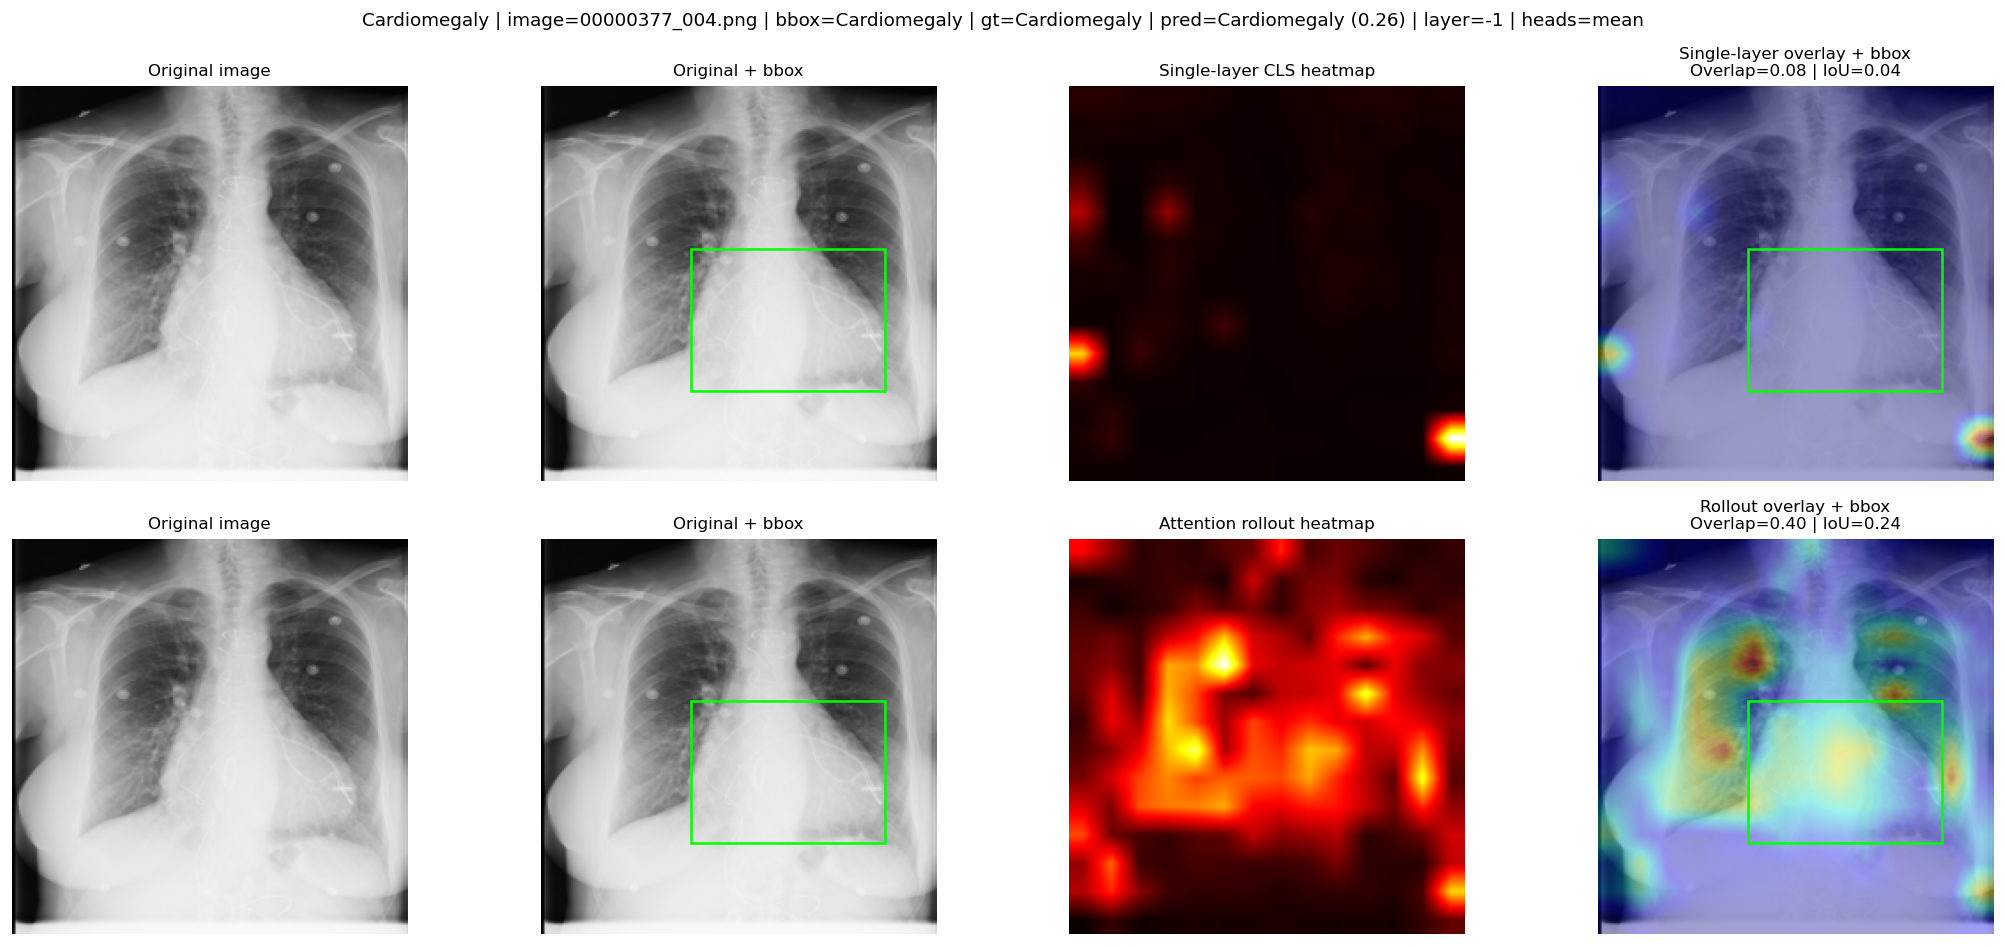

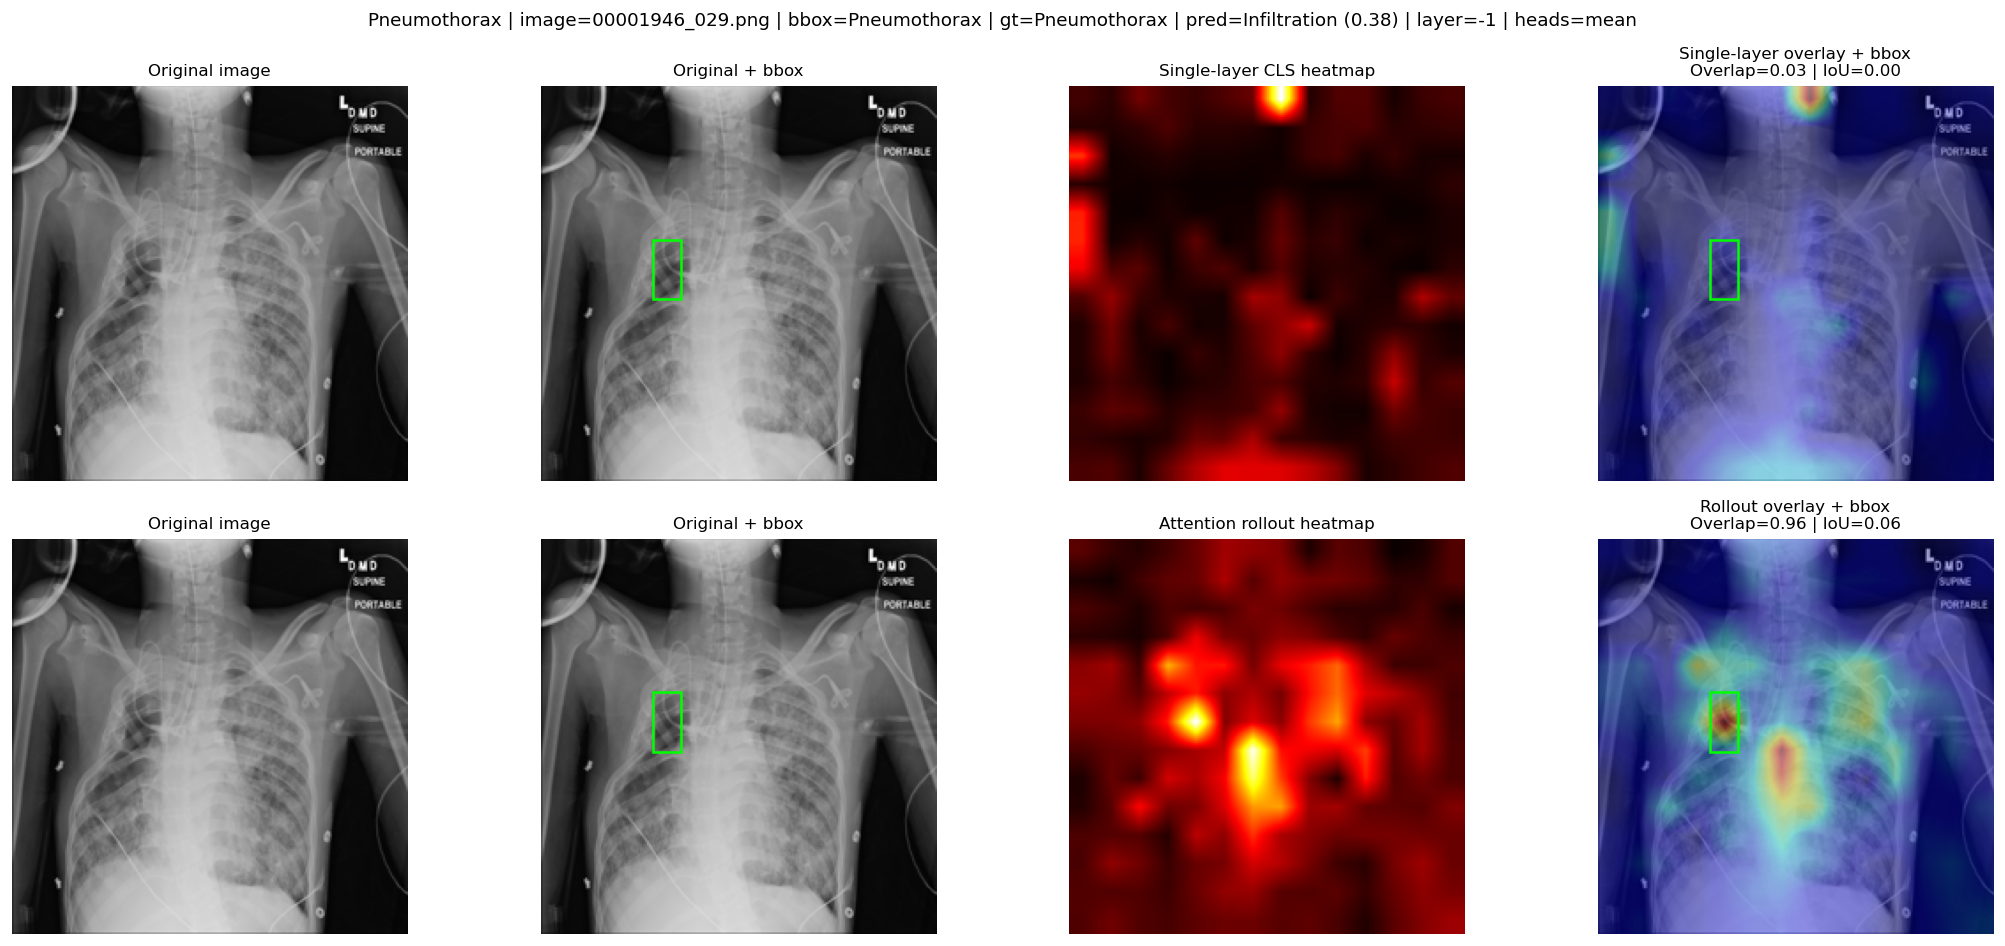

Saved 2 bbox attention figures to /home/nate/Documents/omscs/dl/final_project/visiontrans_diagnostics/artifacts/interpretability/vit_bbox_attention_examples


In [67]:
def plot_vit_attention_bbox_example(record: dict[str, object]) -> plt.Figure:
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))

    axes[0, 0].imshow(record["image_array"])
    axes[0, 0].set_title("Original image")
    axes[0, 1].imshow(record["image_array"])
    axes[0, 1].set_title("Original + bbox")
    axes[0, 2].imshow(record["single_heatmap"].detach().cpu().squeeze(), cmap="hot", vmin=0.0, vmax=1.0)
    axes[0, 2].set_title("Single-layer CLS heatmap")
    axes[0, 3].imshow(record["single_overlay"])
    axes[0, 3].set_title(
        "Single-layer overlay + bbox\n"
        f"Overlap={record['single_metrics']['attention_bbox_overlap']:.2f} | "
        f"IoU={record['single_metrics']['attention_bbox_iou']:.2f}"
    )

    axes[1, 0].imshow(record["image_array"])
    axes[1, 0].set_title("Original image")
    axes[1, 1].imshow(record["image_array"])
    axes[1, 1].set_title("Original + bbox")
    axes[1, 2].imshow(record["rollout_heatmap"].detach().cpu().squeeze(), cmap="hot", vmin=0.0, vmax=1.0)
    axes[1, 2].set_title("Attention rollout heatmap")
    axes[1, 3].imshow(record["rollout_overlay"])
    axes[1, 3].set_title(
        "Rollout overlay + bbox\n"
        f"Overlap={record['rollout_metrics']['attention_bbox_overlap']:.2f} | "
        f"IoU={record['rollout_metrics']['attention_bbox_iou']:.2f}"
    )

    for row in range(2):
        draw_bboxes_on_axis(
            axes[row, 1],
            record["boxes"],
            image_size=image_size,
            original_width=record["original_width"],
            original_height=record["original_height"],
        )
        draw_bboxes_on_axis(
            axes[row, 3],
            record["boxes"],
            image_size=image_size,
            original_width=record["original_width"],
            original_height=record["original_height"],
        )

    for axis in axes.flat:
        axis.axis("off")

    fig.suptitle(
        f"{record['requested_disease']} | image={record['image_name']} | bbox={record['bbox_label_text']} | "
        f"gt={record['gt_label']} | pred={record['pred_top_label']} ({record['pred_top_prob']:.2f}) | "
        f"layer={record['attention_layer_index']} | heads={record['head_reduction']}",
        fontsize=11,
    )
    fig.tight_layout()
    return fig


if selected_subset_loader is None:
    attention_records = []
    print("No selected-sample loader is available, so attention generation cannot proceed.")
else:
    attention_records = generate_attention_records(
        model=model,
        selected_loader=selected_subset_loader,
        selected_case_rows=selected_case_rows,
        selected_case_images=selected_case_images,
        label_names=label_names,
        device=device,
        image_size=image_size,
        patch_size=patch_size,
        mean=mean,
        std=std,
        layer_index=LAYER_INDEX,
        head_reduction=HEAD_REDUCTION,
        rollout_head_reduction=ROLLOUT_HEAD_REDUCTION,
        rollout_discard_ratio=ROLLOUT_DISCARD_RATIO,
        heatmap_percentile=HEATMAP_PERCENTILE,
        top_k=TOP_K_PREDICTIONS,
    )
    print("Generated attention records:", len(attention_records))

saved_paths = []
if not attention_records:
    print("No attention figures were generated. Check the candidate-selection diagnostics above.")
else:
    for sample_index, record in enumerate(attention_records):
        fig = plot_vit_attention_bbox_example(record)
        plt.show()
        output_path = FIGURE_OUTPUT_DIR / (
            f"bbox_case_{sample_index:03d}_{record['requested_disease'].replace(' ', '_')}_{record['image_name'].replace('/', '_')}"
            ".png"
        )
        fig.savefig(output_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        saved_paths.append(output_path)
    print(f"Saved {len(saved_paths)} bbox attention figures to {FIGURE_OUTPUT_DIR}")


In [68]:
metrics_rows = []
for sample_index, record in enumerate(attention_records):
    output_path = str(saved_paths[sample_index]) if sample_index < len(saved_paths) else ""
    metrics_rows.append(
        {
            "requested_disease": record["requested_disease"],
            "dataset_index": record["dataset_index"],
            "image_name": record["image_name"],
            "bbox_labels": record["bbox_label_text"],
            "gt_label": record["gt_label"],
            "true_labels": record["true_label_text"],
            "pred_top_label": record["pred_top_label"],
            "pred_top_prob": record["pred_top_prob"],
            "top_predictions": record["top_prediction_text"],
            "single_layer_attention_bbox_overlap": record["single_metrics"]["attention_bbox_overlap"],
            "single_layer_attention_bbox_iou": record["single_metrics"]["attention_bbox_iou"],
            "single_layer_heatmap_mass_inside_bbox": record["single_metrics"]["heatmap_mass_inside_bbox"],
            "rollout_attention_bbox_overlap": record["rollout_metrics"]["attention_bbox_overlap"],
            "rollout_attention_bbox_iou": record["rollout_metrics"]["attention_bbox_iou"],
            "rollout_heatmap_mass_inside_bbox": record["rollout_metrics"]["heatmap_mass_inside_bbox"],
            "output_path": output_path,
        }
    )

metrics_df = pd.DataFrame(metrics_rows)
if metrics_df.empty:
    print("No localization metrics were produced because no attention records were generated.")
else:
    metrics_df.to_csv(METRICS_CSV, index=False)
    print("Saved localization metrics CSV to:", METRICS_CSV)
    display(metrics_df)


Saved localization metrics CSV to: /home/nate/Documents/omscs/dl/final_project/visiontrans_diagnostics/artifacts/interpretability/vit_bbox_attention_metrics.csv


,requested_disease,dataset_index,image_name,bbox_labels,gt_label,true_labels,pred_top_label,pred_top_prob,top_predictions,single_layer_attention_bbox_overlap,single_layer_attention_bbox_iou,single_layer_heatmap_mass_inside_bbox,rollout_attention_bbox_overlap,rollout_attention_bbox_iou,rollout_heatmap_mass_inside_bbox,output_path
0,Cardiomegaly,395,00000377_004.png,Cardiomegaly,Cardiomegaly,Cardiomegaly,Cardiomegaly,0.263951,"Cardiomegaly=0.26, Effusion=0.22, Atelectasis=...",0.081850,0.040505,0.080283,0.403867,0.237744,0.271488,/home/nate/Documents/omscs/dl/final_project/vi...
1,Pneumothorax,1471,00001946_029.png,Pneumothorax,Pneumothorax,Pneumothorax,Infiltration,0.378723,"Infiltration=0.38, Consolidation=0.26, Effusio...",0.030252,0.001695,0.009443,0.963025,0.056970,0.034772,/home/nate/Documents/omscs/dl/final_project/vi...


In [69]:
print("Interpretability notebook summary")
print("- Split:", SPLIT)
print("- Requested cases:", SELECTED_BBOX_CASES)
print("- FILTER_CORRECT_ARGMAX:", FILTER_CORRECT_ARGMAX)
print("- Selected bbox sample CSV:", SELECTED_SAMPLES_CSV)
print("- Figure directory:", FIGURE_OUTPUT_DIR)
print("- Metrics CSV:", METRICS_CSV)
print("- Attention plots in this notebook are generated from explicitly selected bbox-annotated samples, not random batches.")
print("- To change the cases, edit SELECTED_BBOX_CASES and rerun the candidate-selection and plotting cells.")


Interpretability notebook summary
- Split: test
- Requested cases: [('Cardiomegaly', 0), ('Pneumothorax', 0)]
- FILTER_CORRECT_ARGMAX: False
- Selected bbox sample CSV: /home/nate/Documents/omscs/dl/final_project/visiontrans_diagnostics/artifacts/interpretability/selected_bbox_samples.csv
- Figure directory: /home/nate/Documents/omscs/dl/final_project/visiontrans_diagnostics/artifacts/interpretability/vit_bbox_attention_examples
- Metrics CSV: /home/nate/Documents/omscs/dl/final_project/visiontrans_diagnostics/artifacts/interpretability/vit_bbox_attention_metrics.csv
- Attention plots in this notebook are generated from explicitly selected bbox-annotated samples, not random batches.
- To change the cases, edit SELECTED_BBOX_CASES and rerun the candidate-selection and plotting cells.
